<div style="background:#0032A0; border-radius:10px; padding:14px 18px; margin-bottom:16px;">
  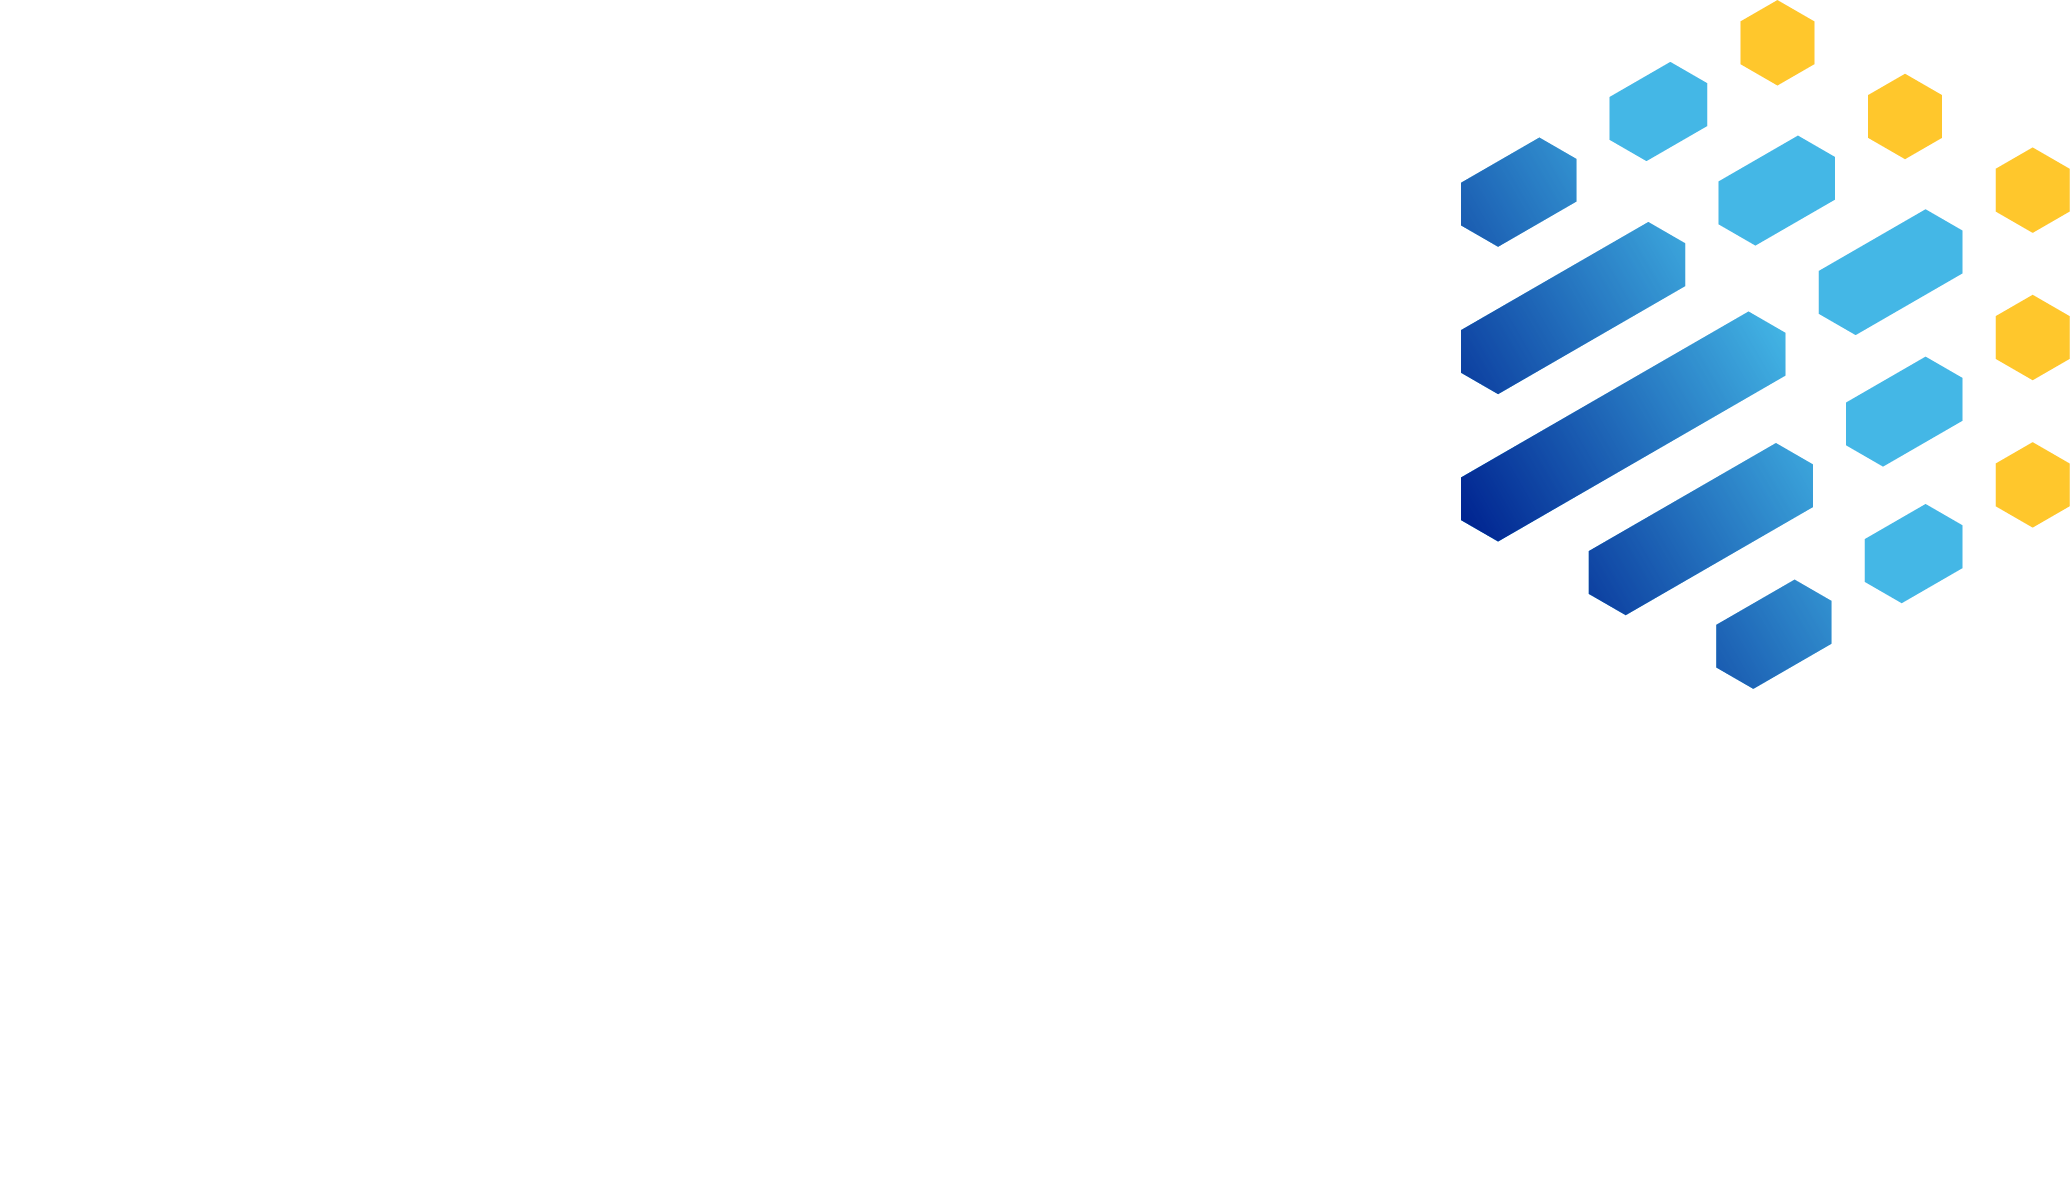
  <div style="color:#FFFFFF; font-size:18px; font-weight:700; font-family:Arial,Helvetica,sans-serif;">Retrosynthesis Example</div>
  <div style="color:#DCE6F5; font-size:14px; margin-top:6px; max-width:70ch;">A worked retrosynthesis-to-literature validation, combining the CAS GraphQL API with a separate CAS Retrosynthesis API.</div>
</div>

# Retrosynthesis Example

This notebook reproduces, end to end, a retrosynthesis pipeline built on two CAS APIs:

1. **CAS GraphQL API** — resolves a CAS Registry Number to its canonical molfile via `substanceQuery { ... on SingleComponentSubstance { molFileV2 } }`.
2. **CAS Retrosynthesis API** (`POST /planJson`) — takes that molfile and returns a full retrosynthetic plan tree (`planElements[]`: molecule nodes and transformation/reaction-step nodes).
3. **CAS GraphQL API** again — for every disconnection in the plan, a forward `reactionQuery(reactionInput: {reactionParticipant: [{RN, role: REACTANT}, ...]})` independently confirms a real CAplus literature reaction matching that exact precursor &rarr; product relationship.

The molecule structures below were pulled from the CAS GraphQL API as **molfiles** (V2000 connection tables) and are rendered here with **RDKit**. The route data (RNs, conditions, reagents, yields, and CAplusAN document identifiers) was captured from the live APIs and is embedded directly below.

Target: **Benzamide, 2-[2-(aminomethyl)-5-chloro-2,3-dihydro-2-phenyl-4-benzofuranyl]-** (RN **3133533-35-1**, C22H19ClN2O2).

Interested in access to either API? Contact [CAS Custom Services](https://www.cas.org/cas-custom-services) to discuss the CAS GraphQL API, the CAS Retrosynthesis API, or both.

<div style="border:1px solid rgba(5,28,44,0.14); border-left:4px solid #c07f00; background:#FBF0DA; border-radius:10px; padding:12px 16px; margin:14px 0;">
<strong>Two separate APIs:</strong> Substance and reaction lookups here use the CAS GraphQL API. The retrosynthetic planning step uses a separate, distinct <strong>CAS Retrosynthesis API</strong> — not part of the GraphQL schema documented elsewhere in this project.</div>

## Setup

In [1]:
import sys, subprocess
try:
    import rdkit  # noqa: F401
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "rdkit"], check=True)

from rdkit import Chem
from rdkit.Chem.Draw import rdMolDraw2D
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.patches import FancyArrowPatch
import pandas as pd
import io, base64


## Molecule data

RNs and molfiles as retrieved from the CAS GraphQL API (`substanceQuery` &rarr; `molFileV2`).

In [2]:
MOLECULES = {
    '3133533-35-1': {
        "name": 'Benzamide, 2-[2-(aminomethyl)-5-chloro-2,3-dihydro-2-phenyl-4-benzofuranyl]-',
        "molfile": '''Benzamide, 2-[2-(aminomethyl)-5-chloro-2,3-dihydro-2-phenyl-4-benzofuranyl]-
C22H19ClN2O2
3133533-35-1 Copyright (C) 2026 ACS
 27 30  0  0  0  0  0  0  0  0999 V2000
    8.1965    1.9307    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    6.9506    1.0255    0.0000 N   0  0  0  0  0  0  0  0  0  0  0  0
    2.2705    6.5808    0.0000 Cl  0  0  0  0  0  0  0  0  0  0  0  0
    3.3705    1.3059    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    2.5544    0.0000    0.0000 N   0  0  0  0  0  0  0  0  0  0  0  0
    4.9096    1.2522    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
    8.0355    3.4623    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    6.5292    3.1421    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    8.1965    4.9938    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
    5.7592    4.4758    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    6.7897    5.6203    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    4.2528    4.7959    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    6.3138    7.0849    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    3.7769    6.2607    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    4.8073    7.4051    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    9.5756    3.4623    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   10.3456    4.7959    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   10.3456    2.1286    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   11.8856    4.7959    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   11.8856    2.1286    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   12.6556    3.4623    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    2.8352    4.1943    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    2.6475    2.6658    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.6053    5.1210    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.2299    2.0639    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.1877    4.5194    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.0000    2.9907    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
  1  2  1  0  0  0  0
  1  7  1  0  0  0  0
  3 14  1  0  0  0  0
  4  5  1  0  0  0  0
  4  6  2  0  0  0  0
  4 23  1  0  0  0  0
  7  8  1  0  0  0  0
  7  9  1  0  0  0  0
  7 16  1  0  0  0  0
  8 10  1  0  0  0  0
  9 11  1  0  0  0  0
 10 11  1  0  0  0  0
 10 12  2  0  0  0  0
 11 13  2  0  0  0  0
 12 14  1  0  0  0  0
 12 22  1  0  0  0  0
 13 15  1  0  0  0  0
 14 15  2  0  0  0  0
 16 17  2  0  0  0  0
 16 18  1  0  0  0  0
 17 19  1  0  0  0  0
 18 20  2  0  0  0  0
 19 21  2  0  0  0  0
 20 21  1  0  0  0  0
 22 23  2  0  0  0  0
 22 24  1  0  0  0  0
 23 25  1  0  0  0  0
 24 26  2  0  0  0  0
 25 27  2  0  0  0  0
 26 27  1  0  0  0  0
M  END
''',
        "terminal": False,
    },
    '3055302-92-3': {
        "name": 'Benzonitrile precursor (nitrile, pre-reduction)',
        "molfile": '''
C22H17ClN2O
3055302-92-3 Copyright (C) 2025 ACS
 26 29  0  0  0  0  0  0  0  0999 V2000
    8.3032    2.0183    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    7.2728    0.8740    0.0000 N   0  0  0  0  0  0  0  0  0  0  0  0
    1.5400    5.3347    0.0000 Cl  0  0  0  0  0  0  0  0  0  0  0  0
    0.7700    4.0011    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.0000    5.3347    0.0000 N   0  0  0  0  0  0  0  0  0  0  0  0
    7.8274    3.4830    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    6.4206    2.8567    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    7.6664    5.0145    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
    5.3900    4.0011    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    6.1600    5.3347    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    3.8500    4.0011    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    5.3900    6.6685    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    3.0800    5.3347    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    3.8500    6.6685    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    9.3338    3.8032    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    9.8096    5.2679    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   10.3642    2.6588    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   11.3159    5.5880    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   11.8705    2.9790    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   12.3465    4.4435    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    3.0800    2.6674    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.5400    2.6674    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    3.8500    1.3338    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.7700    1.3338    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    3.0800    0.0000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.5400    0.0000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
  1  2  1  0  0  0  0
  1  6  1  0  0  0  0
  3 13  1  0  0  0  0
  4  5  3  0  0  0  0
  4 22  1  0  0  0  0
  6  7  1  0  0  0  0
  6  8  1  0  0  0  0
  6 15  1  0  0  0  0
  7  9  1  0  0  0  0
  8 10  1  0  0  0  0
  9 10  1  0  0  0  0
  9 11  2  0  0  0  0
 10 12  2  0  0  0  0
 11 13  1  0  0  0  0
 11 21  1  0  0  0  0
 12 14  1  0  0  0  0
 13 14  2  0  0  0  0
 15 16  2  0  0  0  0
 15 17  1  0  0  0  0
 16 18  1  0  0  0  0
 17 19  2  0  0  0  0
 18 20  2  0  0  0  0
 19 20  1  0  0  0  0
 21 22  2  0  0  0  0
 21 23  1  0  0  0  0
 22 24  1  0  0  0  0
 23 25  2  0  0  0  0
 24 26  2  0  0  0  0
 25 26  1  0  0  0  0
M  END
''',
        "terminal": False,
    },
    '138642-62-3': {
        "name": 'Boronic acid, B-(2-cyanophenyl)-',
        "molfile": '''2-Cyanophenylboronic acid
C7H6BNO2
138642-62-3 Copyright (C) 2025 ACS
 11 11  0  0  0  0  0  0  0  0999 V2000
    4.6200    4.0011    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    6.1600    4.0011    0.0000 N   0  0  0  0  0  0  0  0  0  0  0  0
    3.0800    1.3338    0.0000 B   0  0  0  0  0  0  0  0  0  0  0  0
    4.6200    1.3338    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
    2.3100    0.0000    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
    3.0800    4.0011    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    2.3100    2.6674    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    2.3100    5.3349    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.7700    2.6674    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.7700    5.3349    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.0000    4.0011    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
  1  2  3  0  0  0  0
  1  6  1  0  0  0  0
  3  4  1  0  0  0  0
  3  5  1  0  0  0  0
  3  7  1  0  0  0  0
  6  7  2  0  0  0  0
  6  8  1  0  0  0  0
  7  9  1  0  0  0  0
  8 10  2  0  0  0  0
  9 11  2  0  0  0  0
 10 11  1  0  0  0  0
M  END
''',
        "terminal": True,
    },
    '2711863-64-6': {
        "name": '2-Benzofuranmethanamine, 4-bromo-5-chloro-2,3-dihydro-2-phenyl-',
        "molfile": '''4-Bromo-5-chloro-2,3-dihydro-2-phenyl-2-benzofuranmethanamine
C15H13BrClNO
2711863-64-6 Copyright (C) 2025 ACS
 19 21  0  0  0  0  0  0  0  0999 V2000
    4.0433    1.1444    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    5.0738    0.0000    0.0000 N   0  0  0  0  0  0  0  0  0  0  0  0
    9.2666    1.7935    0.0000 Br  0  0  0  0  0  0  0  0  0  0  0  0
   10.8067    4.4608    0.0000 Cl  0  0  0  0  0  0  0  0  0  0  0  0
    4.5192    2.6091    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    5.9260    1.9826    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    4.6801    4.1407    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
    6.9566    3.1272    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    6.1866    4.4608    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    8.4966    3.1272    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    6.9566    5.7945    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    9.2666    4.4608    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    8.4966    5.7945    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    3.0127    2.9293    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.9823    1.7847    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    2.5369    4.3938    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.4760    2.1049    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.0306    4.7142    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.0000    3.5696    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
  1  2  1  0  0  0  0
  1  5  1  0  0  0  0
  3 10  1  0  0  0  0
  4 12  1  0  0  0  0
  5  6  1  0  0  0  0
  5  7  1  0  0  0  0
  5 14  1  0  0  0  0
  6  8  1  0  0  0  0
  7  9  1  0  0  0  0
  8  9  1  0  0  0  0
  8 10  2  0  0  0  0
  9 11  2  0  0  0  0
 10 12  1  0  0  0  0
 11 13  1  0  0  0  0
 12 13  2  0  0  0  0
 14 15  2  0  0  0  0
 14 16  1  0  0  0  0
 15 17  1  0  0  0  0
 16 18  2  0  0  0  0
 17 19  2  0  0  0  0
 18 19  1  0  0  0  0
M  END
''',
        "terminal": False,
    },
    '2711863-63-5': {
        "name": '2-Benzofurancarboxamide, 4-bromo-5-chloro-2,3-dihydro-2-phenyl-',
        "molfile": '''4-Bromo-5-chloro-2,3-dihydro-2-phenyl-2-benzofurancarboxamide
C15H11BrClNO2
2711863-63-5 Copyright (C) 2025 ACS
 20 22  0  0  0  0  0  0  0  0999 V2000
    4.0433    1.1444    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    5.0737    0.0000    0.0000 N   0  0  0  0  0  0  0  0  0  0  0  0
    2.5369    0.8242    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
    9.2666    1.7935    0.0000 Br  0  0  0  0  0  0  0  0  0  0  0  0
   10.8066    4.4608    0.0000 Cl  0  0  0  0  0  0  0  0  0  0  0  0
    4.5192    2.6091    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    5.9260    1.9826    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    4.6801    4.1406    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
    6.9565    3.1271    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    6.1865    4.4608    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    8.4966    3.1271    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    6.9565    5.7944    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    9.2666    4.4608    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    8.4966    5.7944    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    3.0127    2.9293    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    2.5369    4.3938    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.9823    1.7847    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.0306    4.7141    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.4760    2.1049    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.0000    3.5696    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
  1  2  1  0  0  0  0
  1  3  2  0  0  0  0
  1  6  1  0  0  0  0
  4 11  1  0  0  0  0
  5 13  1  0  0  0  0
  6  7  1  0  0  0  0
  6  8  1  0  0  0  0
  6 15  1  0  0  0  0
  7  9  1  0  0  0  0
  8 10  1  0  0  0  0
  9 10  1  0  0  0  0
  9 11  2  0  0  0  0
 10 12  2  0  0  0  0
 11 13  1  0  0  0  0
 12 14  1  0  0  0  0
 13 14  2  0  0  0  0
 15 16  2  0  0  0  0
 15 17  1  0  0  0  0
 16 18  1  0  0  0  0
 17 19  2  0  0  0  0
 18 20  2  0  0  0  0
 19 20  1  0  0  0  0
M  END
''',
        "terminal": False,
    },
    '2711860-27-2': {
        "name": '2-Benzofurancarboxylic acid, 4-bromo-5-chloro-2,3-dihydro-2-phenyl-',
        "molfile": '''4-Bromo-5-chloro-2,3-dihydro-2-phenyl-2-benzofurancarboxylic acid
C15H10BrClO3
2711860-27-2 Copyright (C) 2025 ACS
 20 22  0  0  0  0  0  0  0  0999 V2000
    4.0433    1.1444    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    5.0737    0.0000    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
    2.5369    0.8242    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
    9.2666    1.7935    0.0000 Br  0  0  0  0  0  0  0  0  0  0  0  0
   10.8066    4.4608    0.0000 Cl  0  0  0  0  0  0  0  0  0  0  0  0
    4.5192    2.6091    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    5.9260    1.9826    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    4.6801    4.1406    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
    6.9565    3.1271    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    6.1865    4.4608    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    8.4966    3.1271    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    6.9565    5.7944    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    9.2666    4.4608    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    8.4966    5.7944    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    3.0127    2.9293    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    2.5369    4.3938    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.9823    1.7847    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.0306    4.7141    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.4760    2.1049    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.0000    3.5696    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
  1  2  1  0  0  0  0
  1  3  2  0  0  0  0
  1  6  1  0  0  0  0
  4 11  1  0  0  0  0
  5 13  1  0  0  0  0
  6  7  1  0  0  0  0
  6  8  1  0  0  0  0
  6 15  1  0  0  0  0
  7  9  1  0  0  0  0
  8 10  1  0  0  0  0
  9 10  1  0  0  0  0
  9 11  2  0  0  0  0
 10 12  2  0  0  0  0
 11 13  1  0  0  0  0
 12 14  1  0  0  0  0
 13 14  2  0  0  0  0
 15 16  2  0  0  0  0
 15 17  1  0  0  0  0
 16 18  1  0  0  0  0
 17 19  2  0  0  0  0
 18 20  2  0  0  0  0
 19 20  1  0  0  0  0
M  END
''',
        "terminal": False,
    },
    '2711860-26-1': {
        "name": '2-Benzofurancarboxylic acid, 4-bromo-5-chloro-2,3-dihydro-2-phenyl-, methyl ester',
        "molfile": '''Methyl 4-bromo-5-chloro-2,3-dihydro-2-phenyl-2-benzofurancarboxylate
C16H12BrClO3
2711860-26-1 Copyright (C) 2025 ACS
 21 23  0  0  0  0  0  0  0  0999 V2000
    4.0433    2.6091    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    5.0737    1.4647    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
    2.5368    2.2889    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
    4.5978    0.0000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    9.2665    3.2582    0.0000 Br  0  0  0  0  0  0  0  0  0  0  0  0
   10.8065    5.9255    0.0000 Cl  0  0  0  0  0  0  0  0  0  0  0  0
    4.5191    4.0738    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    5.9259    3.4474    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    4.6801    5.6053    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
    6.9565    4.5918    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    6.1865    5.9255    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    8.4965    4.5918    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    6.9565    7.2593    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    9.2665    5.9255    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    8.4965    7.2593    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    3.0127    4.3939    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    2.5368    5.8586    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.9823    3.2496    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.0306    6.1788    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.4760    3.5697    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.0000    5.0343    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
  1  2  1  0  0  0  0
  1  3  2  0  0  0  0
  1  7  1  0  0  0  0
  2  4  1  0  0  0  0
  5 12  1  0  0  0  0
  6 14  1  0  0  0  0
  7  8  1  0  0  0  0
  7  9  1  0  0  0  0
  7 16  1  0  0  0  0
  8 10  1  0  0  0  0
  9 11  1  0  0  0  0
 10 11  1  0  0  0  0
 10 12  2  0  0  0  0
 11 13  2  0  0  0  0
 12 14  1  0  0  0  0
 13 15  1  0  0  0  0
 14 15  2  0  0  0  0
 16 17  2  0  0  0  0
 16 18  1  0  0  0  0
 17 19  1  0  0  0  0
 18 20  2  0  0  0  0
 19 21  2  0  0  0  0
 20 21  1  0  0  0  0
M  END
''',
        "terminal": False,
    },
    '2711860-25-0': {
        "name": 'Benzenepropanoic acid, 2-bromo-3-chloro-a,6-dihydroxy-a-phenyl-, methyl ester',
        "molfile": '''Methyl 2-bromo-3-chloro-a,6-dihydroxy-a-phenylbenzenepropanoate
C16H14BrClO4
2711860-25-0 Copyright (C) 2025 ACS
 22 23  0  0  0  0  0  0  0  0999 V2000
    4.6200    3.8500    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    6.1600    3.8500    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    4.6200    2.3100    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    4.6200    5.3900    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
    5.9536    1.5400    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
    3.2864    1.5400    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
    5.9536    0.0000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    9.2400    3.8500    0.0000 Br  0  0  0  0  0  0  0  0  0  0  0  0
    4.6200    6.5173    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
   10.7800    6.5173    0.0000 Cl  0  0  0  0  0  0  0  0  0  0  0  0
    3.0800    3.8500    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    2.3100    2.5162    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    2.3100    5.1836    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.7700    2.5162    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.7700    5.1836    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.0000    3.8500    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    6.9300    5.1836    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    8.4700    5.1836    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    6.1600    6.5173    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    9.2400    6.5173    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    6.9300    7.8509    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    8.4700    7.8509    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
  1  2  1  0  0  0  0
  1  3  1  0  0  0  0
  1  4  1  0  0  0  0
  1 11  1  0  0  0  0
  2 17  1  0  0  0  0
  3  5  1  0  0  0  0
  3  6  2  0  0  0  0
  5  7  1  0  0  0  0
  8 18  1  0  0  0  0
  9 19  1  0  0  0  0
 10 20  1  0  0  0  0
 11 12  2  0  0  0  0
 11 13  1  0  0  0  0
 12 14  1  0  0  0  0
 13 15  2  0  0  0  0
 14 16  2  0  0  0  0
 15 16  1  0  0  0  0
 17 18  2  0  0  0  0
 17 19  1  0  0  0  0
 18 20  1  0  0  0  0
 19 21  2  0  0  0  0
 20 22  2  0  0  0  0
 21 22  1  0  0  0  0
M  END
''',
        "terminal": False,
    },
    '2711860-24-9': {
        "name": 'Benzenepropanoic acid, 2-bromo-3-chloro-a-hydroxy-a-phenyl-6-(phenylmethoxy)-, methyl ester',
        "molfile": '''Methyl 2-bromo-3-chloro-a-hydroxy-a-phenyl-6-(phenylmethoxy)benzenepropanoate
C23H20BrClO4
2711860-24-9 Copyright (C) 2025 ACS
 29 31  0  0  0  0  0  0  0  0999 V2000
    6.1600    5.3347    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    4.6200    5.3347    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    4.6200    6.8747    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    4.6200    3.7947    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
    5.9536    7.6447    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
    3.2864    7.6447    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
    5.9536    9.1847    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    9.2400    5.3347    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
   10.7800    5.3347    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    4.6200    2.6674    0.0000 Br  0  0  0  0  0  0  0  0  0  0  0  0
    6.1600    0.0000    0.0000 Cl  0  0  0  0  0  0  0  0  0  0  0  0
    6.9300    4.0011    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    8.4700    4.0011    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    6.1600    2.6674    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    9.2400    2.6674    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    6.9300    1.3336    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    8.4700    1.3336    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    3.0800    5.3347    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    2.3100    6.6684    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    2.3100    4.0011    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.7700    6.6684    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.7700    4.0011    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.0000    5.3347    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   11.5500    6.6684    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   13.0900    6.6684    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   10.7800    8.0021    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   13.8600    8.0021    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   11.5500    9.3358    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   13.0900    9.3358    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
  1  2  1  0  0  0  0
  1 12  1  0  0  0  0
  2  3  1  0  0  0  0
  2  4  1  0  0  0  0
  2 18  1  0  0  0  0
  3  5  1  0  0  0  0
  3  6  2  0  0  0  0
  5  7  1  0  0  0  0
  8  9  1  0  0  0  0
  8 13  1  0  0  0  0
  9 24  1  0  0  0  0
 10 14  1  0  0  0  0
 11 16  1  0  0  0  0
 12 13  2  0  0  0  0
 12 14  1  0  0  0  0
 13 15  1  0  0  0  0
 14 16  2  0  0  0  0
 15 17  2  0  0  0  0
 16 17  1  0  0  0  0
 18 19  2  0  0  0  0
 18 20  1  0  0  0  0
 19 21  1  0  0  0  0
 20 22  2  0  0  0  0
 21 23  2  0  0  0  0
 22 23  1  0  0  0  0
 24 25  2  0  0  0  0
 24 26  1  0  0  0  0
 25 27  1  0  0  0  0
 26 28  2  0  0  0  0
 27 29  2  0  0  0  0
 28 29  1  0  0  0  0
M  END
''',
        "terminal": False,
    },
    '2711860-23-8': {
        "name": 'Benzenepropanoic acid, 2-bromo-3-chloro-a-phenyl-6-(phenylmethoxy)-a-[(tetrahydro-2H-pyran-2-yl)oxy]-, methyl ester',
        "molfile": '''Methyl 2-bromo-3-chloro-a-phenyl-6-(phenylmethoxy)-a-[(tetrahydro-2H-pyran-2-...
C28H28BrClO5
2711860-23-8 Copyright (C) 2025 ACS
 35 38  0  0  0  0  0  0  0  0999 V2000
    5.3901    4.0010    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    6.7237    4.7710    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    4.6200    5.3348    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
    4.3011    2.9120    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    4.6997    1.4245    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
    2.8136    3.3107    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
    3.6107    0.3356    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    9.3912    6.3110    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
   10.7248    7.0810    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    4.0564    6.3110    0.0000 Br  0  0  0  0  0  0  0  0  0  0  0  0
    4.0564    9.3910    0.0000 Cl  0  0  0  0  0  0  0  0  0  0  0  0
    6.1601    2.6673    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    5.3901    1.3337    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    7.7001    2.6673    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    6.1601    0.0000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    8.4701    1.3337    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    7.7001    0.0000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    6.7237    6.3110    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    8.0575    7.0810    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    5.3901    7.0810    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    8.0575    8.6210    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    5.3901    8.6210    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    6.7237    9.3910    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    3.0800    5.3348    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    2.3100    6.6684    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    2.3100    4.0010    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
    0.7700    6.6684    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.7700    4.0010    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.0000    5.3348    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   12.0585    6.3110    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   12.0585    4.7710    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   13.3923    7.0810    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   13.3923    4.0010    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   14.7259    6.3110    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   14.7259    4.7710    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
  1  2  1  0  0  0  0
  1  3  1  0  0  0  0
  1  4  1  0  0  0  0
  1 12  1  0  0  0  0
  2 18  1  0  0  0  0
  3 24  1  0  0  0  0
  4  5  1  0  0  0  0
  4  6  2  0  0  0  0
  5  7  1  0  0  0  0
  8  9  1  0  0  0  0
  8 19  1  0  0  0  0
  9 30  1  0  0  0  0
 10 20  1  0  0  0  0
 11 22  1  0  0  0  0
 12 13  2  0  0  0  0
 12 14  1  0  0  0  0
 13 15  1  0  0  0  0
 14 16  2  0  0  0  0
 15 17  2  0  0  0  0
 16 17  1  0  0  0  0
 18 19  2  0  0  0  0
 18 20  1  0  0  0  0
 19 21  1  0  0  0  0
 20 22  2  0  0  0  0
 21 23  2  0  0  0  0
 22 23  1  0  0  0  0
 24 25  1  0  0  0  0
 24 26  1  0  0  0  0
 25 27  1  0  0  0  0
 26 28  1  0  0  0  0
 27 29  1  0  0  0  0
 28 29  1  0  0  0  0
 30 31  2  0  0  0  0
 30 32  1  0  0  0  0
 31 33  1  0  0  0  0
 32 34  2  0  0  0  0
 33 35  2  0  0  0  0
 34 35  1  0  0  0  0
M  END
''',
        "terminal": False,
    },
    '2711860-22-7': {
        "name": 'Benzene, 2-bromo-3-(bromomethyl)-1-chloro-4-(phenylmethoxy)-',
        "molfile": '''2-Bromo-3-(bromomethyl)-1-chloro-4-(phenylmethoxy)benzene
C14H11Br2ClO
2711860-22-7 Copyright (C) 2025 ACS
 18 19  0  0  0  0  0  0  0  0999 V2000
    6.1600    4.0011    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
    6.9300    5.3347    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    4.6200    1.3338    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    3.8500    0.0000    0.0000 Br  0  0  0  0  0  0  0  0  0  0  0  0
    1.5400    1.3338    0.0000 Br  0  0  0  0  0  0  0  0  0  0  0  0
    0.0000    4.0011    0.0000 Cl  0  0  0  0  0  0  0  0  0  0  0  0
    4.6200    4.0011    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    3.8500    2.6674    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    3.8500    5.3347    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    2.3100    2.6674    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    2.3100    5.3347    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.5400    4.0011    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    8.4700    5.3347    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    9.2400    6.6685    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    9.2400    4.0011    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   10.7800    6.6685    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   10.7800    4.0011    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   11.5500    5.3347    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
  1  2  1  0  0  0  0
  1  7  1  0  0  0  0
  2 13  1  0  0  0  0
  3  4  1  0  0  0  0
  3  8  1  0  0  0  0
  5 10  1  0  0  0  0
  6 12  1  0  0  0  0
  7  8  2  0  0  0  0
  7  9  1  0  0  0  0
  8 10  1  0  0  0  0
  9 11  2  0  0  0  0
 10 12  2  0  0  0  0
 11 12  1  0  0  0  0
 13 14  2  0  0  0  0
 13 15  1  0  0  0  0
 14 16  1  0  0  0  0
 15 17  2  0  0  0  0
 16 18  2  0  0  0  0
 17 18  1  0  0  0  0
M  END
''',
        "terminal": False,
    },
    '33973-12-5': {
        "name": 'Benzeneacetic acid, a-[(tetrahydro-2H-pyran-2-yl)oxy]-, methyl ester',
        "molfile": '''Methyl a-[(tetrahydro-2H-pyran-2-yl)oxy]benzeneacetate
C14H18O4
33973-12-5 Copyright (C) 2025 ACS
 18 19  0  0  0  0  0  0  0  0999 V2000
    5.3900    4.0011    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    4.6200    5.3347    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
    4.6200    2.6674    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    5.3900    1.3338    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
    3.0800    2.6674    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
    4.6200    0.0000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    6.9300    4.0011    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    7.7000    2.6674    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    7.7000    5.3347    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    9.2400    2.6674    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    9.2400    5.3347    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   10.0100    4.0011    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    3.0800    5.3347    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    2.3100    6.6685    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    2.3100    4.0011    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
    0.7700    6.6685    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.7700    4.0011    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.0000    5.3347    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
  1  2  1  0  0  0  0
  1  3  1  0  0  0  0
  1  7  1  0  0  0  0
  2 13  1  0  0  0  0
  3  4  1  0  0  0  0
  3  5  2  0  0  0  0
  4  6  1  0  0  0  0
  7  8  2  0  0  0  0
  7  9  1  0  0  0  0
  8 10  1  0  0  0  0
  9 11  2  0  0  0  0
 10 12  2  0  0  0  0
 11 12  1  0  0  0  0
 13 14  1  0  0  0  0
 13 15  1  0  0  0  0
 14 16  1  0  0  0  0
 15 17  1  0  0  0  0
 16 18  1  0  0  0  0
 17 18  1  0  0  0  0
M  END
''',
        "terminal": False,
    },
    '2711860-21-6': {
        "name": 'Benzenemethanol, 2-bromo-3-chloro-6-(phenylmethoxy)-',
        "molfile": '''2-Bromo-3-chloro-6-(phenylmethoxy)benzenemethanol
C14H12BrClO2
2711860-21-6 Copyright (C) 2025 ACS
 18 19  0  0  0  0  0  0  0  0999 V2000
    6.1600    4.0011    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
    6.9300    5.3347    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    4.6200    1.3338    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    3.8500    0.0000    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
    1.5400    1.3338    0.0000 Br  0  0  0  0  0  0  0  0  0  0  0  0
    0.0000    4.0011    0.0000 Cl  0  0  0  0  0  0  0  0  0  0  0  0
    4.6200    4.0011    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    3.8500    2.6674    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    3.8500    5.3347    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    2.3100    2.6674    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    2.3100    5.3347    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.5400    4.0011    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    8.4700    5.3347    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    9.2400    6.6685    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    9.2400    4.0011    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   10.7800    6.6685    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   10.7800    4.0011    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   11.5500    5.3347    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
  1  2  1  0  0  0  0
  1  7  1  0  0  0  0
  2 13  1  0  0  0  0
  3  4  1  0  0  0  0
  3  8  1  0  0  0  0
  5 10  1  0  0  0  0
  6 12  1  0  0  0  0
  7  8  2  0  0  0  0
  7  9  1  0  0  0  0
  8 10  1  0  0  0  0
  9 11  2  0  0  0  0
 10 12  2  0  0  0  0
 11 12  1  0  0  0  0
 13 14  2  0  0  0  0
 13 15  1  0  0  0  0
 14 16  1  0  0  0  0
 15 17  2  0  0  0  0
 16 18  2  0  0  0  0
 17 18  1  0  0  0  0
M  END
''',
        "terminal": False,
    },
    '2413838-38-5': {
        "name": 'Benzaldehyde, 2-bromo-3-chloro-6-(phenylmethoxy)-',
        "molfile": '''2-Bromo-3-chloro-6-(phenylmethoxy)benzaldehyde
C14H10BrClO2
2413838-38-5 Copyright (C) 2025 ACS
 18 19  0  0  0  0  0  0  0  0999 V2000
    6.1600    4.0011    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
    6.9300    5.3347    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    4.6200    1.3338    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    3.8500    0.0000    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
    1.5400    1.3338    0.0000 Br  0  0  0  0  0  0  0  0  0  0  0  0
    0.0000    4.0011    0.0000 Cl  0  0  0  0  0  0  0  0  0  0  0  0
    4.6200    4.0011    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    3.8500    2.6674    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    3.8500    5.3347    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    2.3100    2.6674    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    2.3100    5.3347    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.5400    4.0011    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    8.4700    5.3347    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    9.2400    6.6685    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    9.2400    4.0011    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   10.7800    6.6685    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   10.7800    4.0011    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   11.5500    5.3347    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
  1  2  1  0  0  0  0
  1  7  1  0  0  0  0
  2 13  1  0  0  0  0
  3  4  2  0  0  0  0
  3  8  1  0  0  0  0
  5 10  1  0  0  0  0
  6 12  1  0  0  0  0
  7  8  2  0  0  0  0
  7  9  1  0  0  0  0
  8 10  1  0  0  0  0
  9 11  2  0  0  0  0
 10 12  2  0  0  0  0
 11 12  1  0  0  0  0
 13 14  2  0  0  0  0
 13 15  1  0  0  0  0
 14 16  1  0  0  0  0
 15 17  2  0  0  0  0
 16 18  2  0  0  0  0
 17 18  1  0  0  0  0
M  END
''',
        "terminal": True,
    },
    '110-87-2': {
        "name": '2H-Pyran, 3,4-dihydro-',
        "molfile": '''3,4-Dihydro-2H-pyran
C5H8O
110-87-2 Copyright (C) 2025 ACS
  6  6  0  0  0  0  0  0  0  0999 V2000
    0.0000    1.3337    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.7700    0.0000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.7700    2.6673    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    2.3101    0.0000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    2.3101    2.6673    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    3.0801    1.3337    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
  1  2  1  0  0  0  0
  1  3  1  0  0  0  0
  2  4  1  0  0  0  0
  3  5  2  0  0  0  0
  4  6  1  0  0  0  0
  5  6  1  0  0  0  0
M  END
''',
        "terminal": True,
    },
    '4358-87-6': {
        "name": 'Benzeneacetic acid, a-hydroxy-, methyl ester',
        "molfile": '''(+/-)-Methyl mandelate
C9H10O3
4358-87-6 Copyright (C) 2025 ACS
 12 12  0  0  0  0  0  0  0  0999 V2000
    4.0011    1.5400    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    5.3347    2.3100    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    4.0011    0.0000    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
    6.6685    1.5400    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
    5.3347    3.8500    0.0000 O   0  0  0  0  0  0  0  0  0  0  0  0
    8.0021    2.3100    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    2.6674    2.3100    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    2.6674    3.8500    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.3336    1.5400    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.3336    4.6200    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.0000    2.3100    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.0000    3.8500    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
  1  2  1  0  0  0  0
  1  3  1  0  0  0  0
  1  7  1  0  0  0  0
  2  4  1  0  0  0  0
  2  5  2  0  0  0  0
  4  6  1  0  0  0  0
  7  8  2  0  0  0  0
  7  9  1  0  0  0  0
  8 10  1  0  0  0  0
  9 11  2  0  0  0  0
 10 12  2  0  0  0  0
 11 12  1  0  0  0  0
M  END
''',
        "terminal": True,
    },
}

print(f'{len(MOLECULES)} molecules loaded')

16 molecules loaded


## Reaction data

Each step's reagents, conditions, yield, and source document — captured from the forward `reactionQuery` that independently re-confirmed the retrosynthetic plan's prediction against real CAplus literature.

In [3]:
REACTIONS = [
    {
        "step": 1,
        "reactants": ['110-87-2', '4358-87-6'],
        "product": '33973-12-5',
        "label": 'THP protection',
        "reagents": 'PPTS (cat.)',
        "solvent": 'CH2Cl2',
        "conditions": 'rt, 18 h',
        "yield_pct": 60,
        "caplusAN": '2018:1890779',
        "doc_title": 'Au-catalyzed intramolecular hydroalkoxylation of gem-difluorinated alkynols',
        "pub_date": '2018-12-31',
        "reaction_id": '26458672',
        "public_id": '31-236-CAS-19626690',
    },
    {
        "step": 2,
        "reactants": ['2413838-38-5'],
        "product": '2711860-21-6',
        "label": 'Ketone/aldehyde reduction',
        "reagents": 'NaBH4',
        "solvent": 'THF; then acetone',
        "conditions": '0 °C → rt, 3 h',
        "yield_pct": 91,
        "caplusAN": '2022:2312088',
        "doc_title": 'The First Class of Small Molecules Potently Disrupting the YAP-TEAD Interaction by Direct Competition',
        "pub_date": '2022-10-06',
        "reaction_id": '35659231',
        "public_id": '31-614-CAS-34555899',
    },
    {
        "step": 3,
        "reactants": ['2711860-21-6'],
        "product": '2711860-22-7',
        "label": 'Appel bromination',
        "reagents": 'CBr4, PPh3',
        "solvent": 'CH2Cl2',
        "conditions": '0 °C → rt, overnight',
        "yield_pct": 69,
        "caplusAN": '2022:2312088',
        "doc_title": 'The First Class of Small Molecules Potently Disrupting the YAP-TEAD Interaction by Direct Competition',
        "pub_date": '2022-10-06',
        "reaction_id": '35659235',
        "public_id": '31-614-CAS-34555907',
    },
    {
        "step": 4,
        "reactants": ['33973-12-5', '2711860-22-7'],
        "product": '2711860-23-8',
        "label": 'Enolate alkylation',
        "reagents": 'LDA; then NH4Cl quench',
        "solvent": 'THF',
        "conditions": '-78 °C → rt, 3 h',
        "yield_pct": 100,
        "caplusAN": '2022:2312088',
        "doc_title": 'The First Class of Small Molecules Potently Disrupting the YAP-TEAD Interaction by Direct Competition',
        "pub_date": '2022-10-06',
        "reaction_id": '35659240',
        "public_id": '31-614-CAS-34555894',
    },
    {
        "step": 5,
        "reactants": ['2711860-23-8'],
        "product": '2711860-24-9',
        "label": 'THP deprotection',
        "reagents": 'HCl',
        "solvent": 'MeCN / H2O',
        "conditions": 'rt, 3 h',
        "yield_pct": 100,
        "caplusAN": '2022:2312088',
        "doc_title": 'The First Class of Small Molecules Potently Disrupting the YAP-TEAD Interaction by Direct Competition',
        "pub_date": '2022-10-06',
        "reaction_id": '35659244',
        "public_id": '31-614-CAS-34555901',
    },
    {
        "step": 6,
        "reactants": ['2711860-24-9'],
        "product": '2711860-25-0',
        "label": 'Hydrogenolysis (O-Bn removal)',
        "reagents": 'H2',
        "solvent": 'MeOH / THF',
        "conditions": 'rt, 5 h',
        "yield_pct": 99,
        "caplusAN": '2022:2312088',
        "doc_title": 'The First Class of Small Molecules Potently Disrupting the YAP-TEAD Interaction by Direct Competition',
        "pub_date": '2022-10-06',
        "reaction_id": '35659247',
        "public_id": '31-614-CAS-34555897',
    },
    {
        "step": 7,
        "reactants": ['2711860-25-0'],
        "product": '2711860-26-1',
        "label": 'Mitsunobu cyclization',
        "reagents": 'PPh3, DIAD',
        "solvent": 'THF',
        "conditions": '0 °C → rt, 3 h',
        "yield_pct": 66,
        "caplusAN": '2022:2312088',
        "doc_title": 'The First Class of Small Molecules Potently Disrupting the YAP-TEAD Interaction by Direct Competition',
        "pub_date": '2022-10-06',
        "reaction_id": '35659250',
        "public_id": '31-614-CAS-34555893',
    },
    {
        "step": 8,
        "reactants": ['2711860-26-1'],
        "product": '2711860-27-2',
        "label": 'Ester hydrolysis',
        "reagents": 'NaOH; then HCl',
        "solvent": 'MeOH / THF; H2O',
        "conditions": 'rt, 15 min (pH 2 workup)',
        "yield_pct": 74,
        "caplusAN": '2022:2312088',
        "doc_title": 'The First Class of Small Molecules Potently Disrupting the YAP-TEAD Interaction by Direct Competition',
        "pub_date": '2022-10-06',
        "reaction_id": '35659254',
        "public_id": '31-614-CAS-34555906',
    },
    {
        "step": 9,
        "reactants": ['2711860-27-2'],
        "product": '2711863-63-5',
        "label": 'Acid → amide',
        "reagents": '(COCl)2, DMF (cat.); then NH4OH',
        "solvent": 'CH2Cl2; H2O',
        "conditions": '0 °C → rt, 30 min',
        "yield_pct": None,
        "caplusAN": '2022:2312088',
        "doc_title": 'The First Class of Small Molecules Potently Disrupting the YAP-TEAD Interaction by Direct Competition',
        "pub_date": '2022-10-06',
        "reaction_id": '35659276',
        "public_id": '31-614-CAS-34555905',
    },
    {
        "step": 10,
        "reactants": ['2711863-63-5'],
        "product": '2711863-64-6',
        "label": 'Amide reduction',
        "reagents": 'BH3·SMe2; then HCl',
        "solvent": 'THF; MeOH; H2O',
        "conditions": 'reflux, 5 h',
        "yield_pct": 78,
        "caplusAN": '2022:2312088',
        "doc_title": 'The First Class of Small Molecules Potently Disrupting the YAP-TEAD Interaction by Direct Competition',
        "pub_date": '2022-10-06',
        "reaction_id": '35659278',
        "public_id": '31-614-CAS-34555912',
    },
    {
        "step": 11,
        "reactants": ['2711863-64-6', '138642-62-3'],
        "product": '3055302-92-3',
        "label": 'Suzuki coupling',
        "reagents": 'K3PO4, Pd(dppf)Cl2·CH2Cl2',
        "solvent": '1,4-dioxane / H2O',
        "conditions": '100 °C, 4 h',
        "yield_pct": 69,
        "caplusAN": '2022:2312088',
        "doc_title": 'The First Class of Small Molecules Potently Disrupting the YAP-TEAD Interaction by Direct Competition',
        "pub_date": '2022-10-06',
        "reaction_id": '35659280',
        "public_id": '31-614-CAS-34555916',
    },
    {
        "step": 12,
        "reactants": ['3055302-92-3'],
        "product": '3133533-35-1',
        "label": 'Nitrile hydration to amide (target)',
        "reagents": 'Pt(PMe2)2H catalyst',
        "solvent": 'EtOH / H2O',
        "conditions": '80 °C, 2 h',
        "yield_pct": 34,
        "caplusAN": '2022:2312088',
        "doc_title": 'The First Class of Small Molecules Potently Disrupting the YAP-TEAD Interaction by Direct Competition',
        "pub_date": '2022-10-06',
        "reaction_id": '35659281',
        "public_id": '31-614-CAS-34555915',
    },
]

print(f'{len(REACTIONS)} reaction steps loaded')

12 reaction steps loaded


## Render structures with RDKit

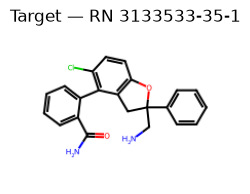

In [4]:
def mol_image_array(rn, width=220, height=150):
    """Render a molfile straight to a bitmap via RDKit's built-in Cairo
    backend (statically linked into the RDKit wheel — no system cairo
    library required, unlike cairosvg)."""
    mol = Chem.MolFromMolBlock(MOLECULES[rn]["molfile"])
    d = rdMolDraw2D.MolDraw2DCairo(width, height)
    opts = d.drawOptions()
    opts.padding = 0.14
    rdMolDraw2D.PrepareAndDrawMolecule(d, mol)
    d.FinishDrawing()
    png_bytes = d.GetDrawingText()
    return mpimg.imread(io.BytesIO(png_bytes))

# quick sanity check: draw the target
plt.figure(figsize=(3, 2))
plt.imshow(mol_image_array("3133533-35-1"))
plt.axis("off")
plt.title("Target — RN 3133533-35-1")
plt.show()


## Lay out the full retrosynthetic route

Backbone left-to-right in synthetic order; the alkylating-agent side chain (steps 2-3) and the two convergent building-block pairs (steps 1, 4, 11) are drawn as they actually react.


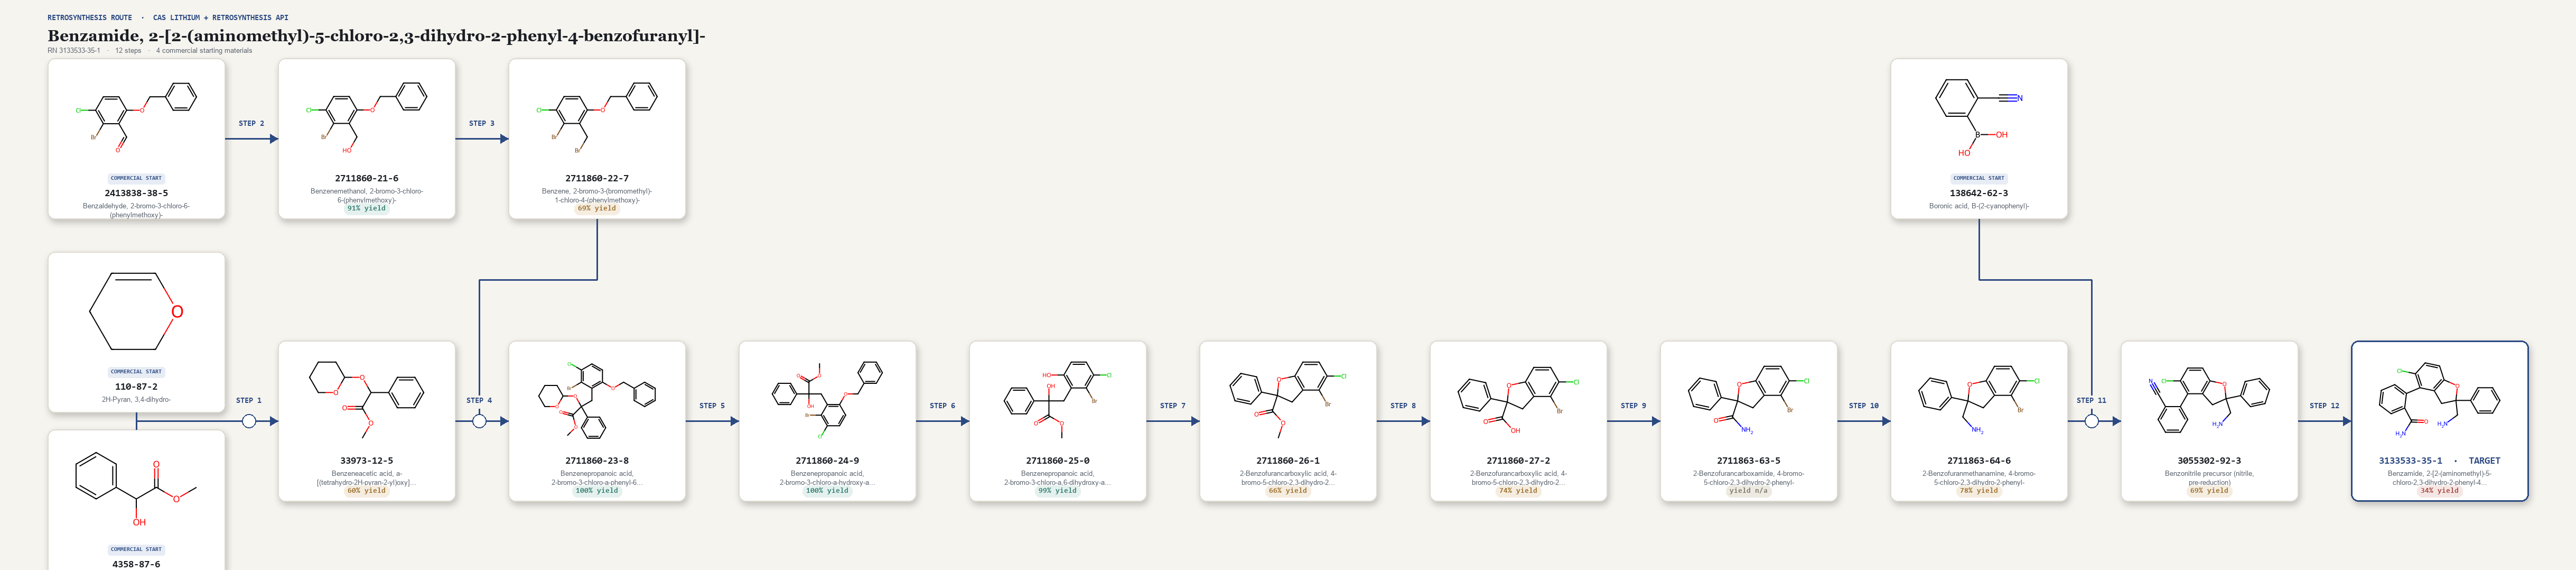

In [5]:
import math, textwrap
from PIL import Image, ImageDraw, ImageFont, ImageFilter

# ---- palette (same tokens as the published HTML route diagram) ----
BG          = (246, 244, 239)
SURFACE     = (255, 255, 255)
INK         = (27, 30, 36)
INK_MUTED   = (92, 101, 112)
INK_FAINT   = (139, 144, 153)
RULE        = (222, 218, 208)
ACCENT      = (44, 74, 130)
ACCENT_SOFT = (231, 236, 245)
YIELD = {
    "high": ((47, 123, 110), (229, 241, 238)),
    "mid":  ((154, 107, 38), (245, 237, 224)),
    "low":  ((165, 66, 58),  (245, 231, 229)),
    "na":   ((124, 117, 102),(237, 234, 226)),
}
def yield_bucket(y):
    if y is None: return "na"
    if y >= 80: return "high"
    if y >= 50: return "mid"
    return "low"

# Column index (not pixels) for each backbone node, left -> right.
BACKBONE_COL = {
    "33973-12-5": 0, "2711860-23-8": 1, "2711860-24-9": 2, "2711860-25-0": 3,
    "2711860-26-1": 4, "2711860-27-2": 5, "2711863-63-5": 6, "2711863-64-6": 7,
    "3055302-92-3": 8, "3133533-35-1": 9,
}
# Nodes that merge into the backbone from a row above/below.
LEFT_PAIR = [("110-87-2", -1), ("4358-87-6", 1)]
BRANCH_ROW = [("2413838-38-5", -1), ("2711860-21-6", 0), ("2711860-22-7", 1)]
TOP_MERGE = ("138642-62-3", 7)  # paired above its actual reaction partner, 2711863-64-6 (both react in step 11)
TERMINAL_RNS = {"110-87-2", "4358-87-6", "2413838-38-5", "138642-62-3"}
RN_TO_STEP_YIELD = {r["product"]: r["yield_pct"] for r in REACTIONS}

MOL_W, MOL_H = 300, 190
BOX_PAD = 18
LABEL_H = 78
BOX_W = MOL_W + 2 * BOX_PAD
BOX_H = MOL_H + 2 * BOX_PAD + LABEL_H
COL_GAP = 100
ROW_GAP = 230  # must clear the left starting-material pair, which extends
                # BOX_H/2 + 16 past the backbone row on top of a normal box
COL_PITCH = BOX_W + COL_GAP
ROW_PITCH = BOX_H + ROW_GAP

MARGIN_X, MARGIN_Y = 90, 110
ORIGIN_X = MARGIN_X + BOX_W // 2 + COL_PITCH
BACKBONE_Y = MARGIN_Y + ROW_PITCH + BOX_H // 2
BRANCH_Y = MARGIN_Y + BOX_H // 2

def col_x(col):
    return ORIGIN_X + col * COL_PITCH

CENTERS = {}
for rn, col in BACKBONE_COL.items():
    CENTERS[rn] = (col_x(col), BACKBONE_Y)
for rn, slot in LEFT_PAIR:
    CENTERS[rn] = (col_x(-1), BACKBONE_Y + slot * (BOX_H // 2 + 16))
for rn, col in BRANCH_ROW:
    CENTERS[rn] = (col_x(col), BRANCH_Y)
CENTERS[TOP_MERGE[0]] = (col_x(TOP_MERGE[1]), BRANCH_Y)

CANVAS_W = col_x(max(BACKBONE_COL.values())) + BOX_W // 2 + MARGIN_X
CANVAS_H = BACKBONE_Y + BOX_H // 2 + MARGIN_Y + 20

def load_font(candidates, size):
    for name in candidates:
        try:
            return ImageFont.truetype(name, size)
        except Exception:
            continue
    return ImageFont.load_default()

font_eyebrow  = load_font(["consolab.ttf", "DejaVuSansMono-Bold.ttf"], 15)
font_title    = load_font(["georgiab.ttf", "Georgia Bold.ttf", "DejaVuSerif-Bold.ttf"], 30)
font_rn       = load_font(["consolab.ttf", "DejaVuSansMono-Bold.ttf"], 19)
font_name     = load_font(["arial.ttf", "Helvetica.ttc", "DejaVuSans.ttf"], 13)
font_badge    = load_font(["consolab.ttf", "DejaVuSansMono-Bold.ttf"], 14)
font_step     = load_font(["consolab.ttf", "DejaVuSansMono-Bold.ttf"], 15)
font_tag      = load_font(["consolab.ttf", "DejaVuSansMono-Bold.ttf"], 11)

canvas = Image.new("RGB", (CANVAS_W, CANVAS_H), BG)
draw = ImageDraw.Draw(canvas)

def rdkit_mol_image(rn):
    mol = Chem.MolFromMolBlock(MOLECULES[rn]["molfile"])
    d = rdMolDraw2D.MolDraw2DCairo(MOL_W, MOL_H)
    opts = d.drawOptions()
    opts.padding = 0.12
    rdMolDraw2D.PrepareAndDrawMolecule(d, mol)
    d.FinishDrawing()
    return Image.open(io.BytesIO(d.GetDrawingText())).convert("RGB")

def text_w(s, f):
    return draw.textlength(s, font=f)

def centered_text(cx, y, s, f, fill):
    draw.text((cx - text_w(s, f) / 2, y), s, font=f, fill=fill)

def wrapped_name(name, width_chars=34, max_lines=2):
    lines = textwrap.wrap(name, width=width_chars)[:max_lines]
    if len(lines) == max_lines and len(textwrap.wrap(name, width=width_chars)) > max_lines:
        lines[-1] = lines[-1].rstrip(",.-") + "..."
    return lines

# ---- pass 1: soft drop shadow behind every box ----
shadow = Image.new("RGBA", canvas.size, (0, 0, 0, 0))
sdraw = ImageDraw.Draw(shadow)
for rn, (cx, cy) in CENTERS.items():
    left, top = cx - BOX_W // 2, cy - BOX_H // 2
    right, bottom = cx + BOX_W // 2, cy + BOX_H // 2
    sdraw.rounded_rectangle([left + 3, top + 6, right + 3, bottom + 6], radius=14, fill=(20, 18, 14, 60))
shadow = shadow.filter(ImageFilter.GaussianBlur(6))
canvas.paste(Image.new("RGB", canvas.size, BG), (0, 0))
canvas = Image.alpha_composite(canvas.convert("RGBA"), shadow).convert("RGB")
draw = ImageDraw.Draw(canvas)

# ---- pass 2: boxes ----
BOXES = {}
for rn, (cx, cy) in CENTERS.items():
    is_target = rn == "3133533-35-1"
    is_terminal = rn in TERMINAL_RNS
    left, top = cx - BOX_W // 2, cy - BOX_H // 2
    right, bottom = cx + BOX_W // 2, cy + BOX_H // 2
    BOXES[rn] = (left, top, right, bottom)

    border = ACCENT if is_target else RULE
    draw.rounded_rectangle([left, top, right, bottom], radius=14,
                            outline=border, width=3 if is_target else 2, fill=SURFACE)

    mol_img = rdkit_mol_image(rn)
    canvas.paste(mol_img, (int(cx - MOL_W // 2), int(top + BOX_PAD)))
    draw = ImageDraw.Draw(canvas)

    text_top = top + BOX_PAD + MOL_H + 10
    if is_terminal:
        tag = "COMMERCIAL START"
        tw = text_w(tag, font_tag)
        pad = 6
        draw.rounded_rectangle([cx - tw / 2 - pad, text_top, cx + tw / 2 + pad, text_top + 20],
                                radius=5, fill=ACCENT_SOFT)
        draw.text((cx - tw / 2, text_top + 3), tag, font=font_tag, fill=ACCENT)
        text_top += 28

    rn_label = rn + ("  ·  TARGET" if is_target else "")
    centered_text(cx, text_top, rn_label, font_rn, ACCENT if is_target else INK)
    text_top += 26

    for line in wrapped_name(MOLECULES[rn]["name"]):
        centered_text(cx, text_top, line, font_name, INK_MUTED)
        text_top += 17

    if rn in RN_TO_STEP_YIELD:
        yp = RN_TO_STEP_YIELD[rn]
        bucket = yield_bucket(yp)
        fg, bgc = YIELD[bucket]
        label = f"{yp}% yield" if yp is not None else "yield n/a"
        tw = text_w(label, font_badge)
        pad = 7
        by = bottom - 30
        draw.rounded_rectangle([cx - tw / 2 - pad, by, cx + tw / 2 + pad, by + 22], radius=10, fill=bgc)
        draw.text((cx - tw / 2, by + 3), label, font=font_badge, fill=fg)

def edge_point(rn, toward_xy):
    cx, cy = CENTERS[rn]
    tx, ty = toward_xy
    left, top, right, bottom = BOXES[rn]
    dx, dy = tx - cx, ty - cy
    if abs(dx) < 1 and abs(dy) < 1:
        return cx, cy
    if abs(dx) > abs(dy):
        return (right if dx > 0 else left), cy
    return cx, (bottom if dy > 0 else top)

def draw_arrow(p0, p1, label=None):
    x0, y0 = p0
    x1, y1 = p1
    draw.line([x0, y0, x1, y1], fill=ACCENT, width=3)
    ang = math.atan2(y1 - y0, x1 - x0)
    hl, hw = 15, 9
    hx, hy = x1 - hl * math.cos(ang), y1 - hl * math.sin(ang)
    lx, ly = hx - hw * math.sin(ang), hy + hw * math.cos(ang)
    rx, ry = hx + hw * math.sin(ang), hy - hw * math.cos(ang)
    draw.polygon([(x1, y1), (lx, ly), (rx, ry)], fill=ACCENT)
    if label:
        mx, my = (x0 + x1) / 2, (y0 + y1) / 2
        lw = text_w(label, font_step)
        pad = 6
        if abs(y1 - y0) < abs(x1 - x0):
            ly2 = my - 27
        else:
            ly2, mx = my, mx + 30
        draw.rounded_rectangle([mx - lw / 2 - pad, ly2 - 11, mx + lw / 2 + pad, ly2 + 13], radius=8, fill=BG)
        draw.text((mx - lw / 2, ly2 - 9), label, font=font_step, fill=ACCENT)

ROW_GAP_MID = (BRANCH_Y + BOX_H // 2 + BACKBONE_Y - BOX_H // 2) / 2  # the empty corridor between the two rows

def elbow_path_into(rn, circle_xy):
    """Waypoints from rn's box to circle_xy: a straight line if already
    aligned, otherwise a clean right-angle elbow — matching the CAS plan
    viewer's own branch connector, mirrored (reactants converge in rather
    than branches diverging out).

    A branch-row reactant (e.g. a node stacked above its actual reaction
    partner) can share its column with a box back on the backbone row, so
    dropping straight down to the circle's y would cut through that box.
    Routing the horizontal leg through the empty corridor between the two
    rows first, then a short final drop into the circle, avoids that."""
    cx, cy = CENTERS[rn]
    circ_x, circ_y = circle_xy
    left, top, right, bottom = BOXES[rn]
    if abs(cy - circ_y) < 1:
        start = (right if circ_x > cx else left), cy
        return [start, circle_xy]
    if abs(cy - BRANCH_Y) < 1:
        return [(cx, bottom), (cx, ROW_GAP_MID), (circ_x, ROW_GAP_MID), circle_xy]
    corner = (cx, bottom if circ_y > cy else top)
    return [corner, (cx, circ_y), circle_xy]

def draw_polyline(points):
    for a, b in zip(points, points[1:]):
        draw.line([a, b], fill=ACCENT, width=3)

CIRCLE_R = 13

def draw_convergent_reaction(reactants, product, label):
    """Single reactant: one straight labeled arrow in, as before.
    Multiple reactants: each connects via a straight line or right-angle
    elbow into a small circle marker sitting on the main chain just before
    the product, and a single labeled arrow continues from that circle into
    the product — matching the CAS plan viewer's own junction-circle
    convention, reversed (reactants converge in rather than branches
    diverging out)."""
    if len(reactants) == 1:
        rn = reactants[0]
        start = edge_point(rn, CENTERS[product])
        end = edge_point(product, CENTERS[rn])
        draw_arrow(start, end, label)
        return

    p_left, p_top, p_right, p_bottom = BOXES[product]
    circle_xy = (p_left - 55, CENTERS[product][1])
    for rn in reactants:
        draw_polyline(elbow_path_into(rn, circle_xy))
    cx, cy = circle_xy
    end = edge_point(product, circle_xy)
    draw_arrow(circle_xy, end, None)  # short final hop into the product; label goes by the circle instead
    draw.ellipse([cx - CIRCLE_R, cy - CIRCLE_R, cx + CIRCLE_R, cy + CIRCLE_R], fill=SURFACE, outline=ACCENT, width=2)
    if label:
        lw = text_w(label, font_step)
        pad = 6
        ly = cy - CIRCLE_R - 24
        draw.rounded_rectangle([cx - lw / 2 - pad, ly - 11, cx + lw / 2 + pad, ly + 13], radius=8, fill=BG)
        draw.text((cx - lw / 2, ly - 9), label, font=font_step, fill=ACCENT)

for r in REACTIONS:
    label = f"STEP {r['step']}"
    draw_convergent_reaction(r["reactants"], r["product"], label)

# ---- title block ----
draw.text((MARGIN_X, 26), "RETROSYNTHESIS ROUTE  ·  CAS LITHIUM + RETROSYNTHESIS API", font=font_eyebrow, fill=ACCENT)
draw.text((MARGIN_X, 50), "Benzamide, 2-[2-(aminomethyl)-5-chloro-2,3-dihydro-2-phenyl-4-benzofuranyl]-", font=font_title, fill=INK)
draw.text((MARGIN_X, 88), "RN 3133533-35-1   ·   12 steps   ·   4 commercial starting materials", font=font_name, fill=INK_MUTED)

buf = io.BytesIO()
canvas.save(buf, format="PNG")
buf.seek(0)
b64 = base64.b64encode(buf.read()).decode("ascii")

# Jupyter's default inline image display shrinks wide images to fit the
# notebook width, which is what made the structures look small in the first
# place — wrapping the native-resolution PNG in a horizontally scrollable
# <div> keeps every structure full-size and crisp instead.
from IPython.display import HTML, display
display(HTML(
    f'<div style="overflow-x:auto; overflow-y:hidden; background:rgb{BG}; border:1px solid #ddd; border-radius:10px; padding:0;">'
    f'<img src="data:image/png;base64,{b64}" style="height:680px; width:auto; max-width:none; display:block;">'
    '</div>'
))


## Full reaction table

Reagents, conditions, yield, and the CAplusAN of the CAplus document each step was confirmed against.

In [6]:
df = pd.DataFrame(REACTIONS)
df["reactants"] = df["reactants"].apply(lambda rs: " + ".join(rs))
df["yield"] = df["yield_pct"].apply(lambda y: f"{y}%" if y is not None else "–")
display_cols = ["step", "reactants", "product", "label", "reagents", "solvent", "conditions", "yield", "caplusAN", "doc_title"]
df[display_cols].set_index("step")


,reactants,product,label,reagents,solvent,conditions,yield,caplusAN,doc_title
step,,,,,,,,,
1,110-87-2 + 4358-87-6,33973-12-5,THP protection,PPTS (cat.),CH2Cl2,"rt, 18 h",60.0%,2018:1890779,Au-catalyzed intramolecular hydroalkoxylation ...
2,2413838-38-5,2711860-21-6,Ketone/aldehyde reduction,NaBH4,THF; then acetone,"0 °C → rt, 3 h",91.0%,2022:2312088,The First Class of Small Molecules Potently Di...
3,2711860-21-6,2711860-22-7,Appel bromination,"CBr4, PPh3",CH2Cl2,"0 °C → rt, overnight",69.0%,2022:2312088,The First Class of Small Molecules Potently Di...
4,33973-12-5 + 2711860-22-7,2711860-23-8,Enolate alkylation,LDA; then NH4Cl quench,THF,"-78 °C → rt, 3 h",100.0%,2022:2312088,The First Class of Small Molecules Potently Di...
5,2711860-23-8,2711860-24-9,THP deprotection,HCl,MeCN / H2O,"rt, 3 h",100.0%,2022:2312088,The First Class of Small Molecules Potently Di...
6,2711860-24-9,2711860-25-0,Hydrogenolysis (O-Bn removal),H2,MeOH / THF,"rt, 5 h",99.0%,2022:2312088,The First Class of Small Molecules Potently Di...
7,2711860-25-0,2711860-26-1,Mitsunobu cyclization,"PPh3, DIAD",THF,"0 °C → rt, 3 h",66.0%,2022:2312088,The First Class of Small Molecules Potently Di...
8,2711860-26-1,2711860-27-2,Ester hydrolysis,NaOH; then HCl,MeOH / THF; H2O,"rt, 15 min (pH 2 workup)",74.0%,2022:2312088,The First Class of Small Molecules Potently Di...
9,2711860-27-2,2711863-63-5,Acid → amide,"(COCl)2, DMF (cat.); then NH4OH",CH2Cl2; H2O,"0 °C → rt, 30 min",nan%,2022:2312088,The First Class of Small Molecules Potently Di...


## Starting materials

The route bottoms out in four commercially available building blocks:

| RN | Name |
|---|---|
| 110-87-2 | 3,4-Dihydro-2H-pyran |
| 4358-87-6 | Methyl mandelate |
| 2413838-38-5 | 2-Bromo-3-chloro-6-(benzyloxy)benzaldehyde |
| 138642-62-3 | 2-Cyanophenylboronic acid |

## Methodology note

Every one of the 12 disconnections above was independently re-confirmed with a forward `reactionQuery` against the CAS GraphQL API — filtering by each step's reactant RN(s) with `role: REACTANT` — rather than trusting the retrosynthesis plan's prediction on its own. In every case the matched literature reaction's `scheme` (`products=reactants`) exactly reproduced the retro-predicted precursor &rarr; product relationship, giving a full round-trip validation of the route with no gaps.


## Appendix: the CAS GraphQL queries used

The four query shapes that produced the data embedded in this notebook are saved as real, runnable `.graphql` files in [`queries/retrosynthesis/`](../queries/retrosynthesis/) — reuse them directly for a different target RN. All four assume a GraphQL client configured with a resolved bearer token against `https://lithium.cas.org/graphql`, and were run live to confirm they still match the embedded data above; the retrosynthetic planning step itself (`POST /planJson`) is a separate API and wasn't re-run here.

- [`resolve-rn-to-molfile.graphql`](../queries/retrosynthesis/resolve-rn-to-molfile.graphql) — resolve an RN to its molfile
- [`resolve-rn-to-molfile-and-image.graphql`](../queries/retrosynthesis/resolve-rn-to-molfile-and-image.graphql) — molfile + SVG + preferred name (used for every molecule in the route)
- [`forward-validate-reaction.graphql`](../queries/retrosynthesis/forward-validate-reaction.graphql) — confirm a real literature reaction matches a predicted disconnection
- [`full-reaction-detail.graphql`](../queries/retrosynthesis/full-reaction-detail.graphql) — pull full reagent/condition/document detail for a matched reaction


<div style="margin:16px 0;"><a href="00_Overview.ipynb" style="display:inline-block; padding:5px 12px; border-radius:999px; background:#E6EAF6; color:#0032A0; font-size:12.5px; text-decoration:none; margin:3px 4px 3px 0;">Overview</a><a href="01_Authentication.ipynb" style="display:inline-block; padding:5px 12px; border-radius:999px; background:#E6EAF6; color:#0032A0; font-size:12.5px; text-decoration:none; margin:3px 4px 3px 0;">Authentication</a><a href="02_Using_GraphiQL.ipynb" style="display:inline-block; padding:5px 12px; border-radius:999px; background:#E6EAF6; color:#0032A0; font-size:12.5px; text-decoration:none; margin:3px 4px 3px 0;">Using GraphiQL</a><a href="03_Substance_Query.ipynb" style="display:inline-block; padding:5px 12px; border-radius:999px; background:#E6EAF6; color:#0032A0; font-size:12.5px; text-decoration:none; margin:3px 4px 3px 0;">Substance</a><a href="04_Reaction_Query.ipynb" style="display:inline-block; padding:5px 12px; border-radius:999px; background:#E6EAF6; color:#0032A0; font-size:12.5px; text-decoration:none; margin:3px 4px 3px 0;">Reaction</a><a href="05_Document_Query.ipynb" style="display:inline-block; padding:5px 12px; border-radius:999px; background:#E6EAF6; color:#0032A0; font-size:12.5px; text-decoration:none; margin:3px 4px 3px 0;">Document</a><a href="06_Property_Query.ipynb" style="display:inline-block; padding:5px 12px; border-radius:999px; background:#E6EAF6; color:#0032A0; font-size:12.5px; text-decoration:none; margin:3px 4px 3px 0;">Property</a><a href="07_Catalog_Query.ipynb" style="display:inline-block; padding:5px 12px; border-radius:999px; background:#E6EAF6; color:#0032A0; font-size:12.5px; text-decoration:none; margin:3px 4px 3px 0;">Catalog</a><a href="08_Hazard_Query.ipynb" style="display:inline-block; padding:5px 12px; border-radius:999px; background:#E6EAF6; color:#0032A0; font-size:12.5px; text-decoration:none; margin:3px 4px 3px 0;">Hazard</a><a href="09_Concept_Query.ipynb" style="display:inline-block; padding:5px 12px; border-radius:999px; background:#E6EAF6; color:#0032A0; font-size:12.5px; text-decoration:none; margin:3px 4px 3px 0;">Concept</a><a href="10_Biosequence_Query.ipynb" style="display:inline-block; padding:5px 12px; border-radius:999px; background:#E6EAF6; color:#0032A0; font-size:12.5px; text-decoration:none; margin:3px 4px 3px 0;">Biosequence</a><a href="11_Miscellaneous_Use_Cases.ipynb" style="display:inline-block; padding:5px 12px; border-radius:999px; background:#E6EAF6; color:#0032A0; font-size:12.5px; text-decoration:none; margin:3px 4px 3px 0;">Misc Use Cases</a><span style="display:inline-block; padding:5px 12px; border-radius:999px; background:#0032A0; color:#FFFFFF; font-size:12.5px; font-weight:700; margin:3px 4px 3px 0;">Retrosynthesis</span></div><hr style="border:none; border-top:1px solid rgba(5,28,44,0.14); margin:28px 0 14px;"><div style="color:#5A656C; font-size:12px;">CAS Registry&reg;, CAS Registry Number&reg;, CAS Commercial Sources&trade;, and CAS Custom Services&#8480; are marks of the American Chemical Society.</div>